# Exploratory Analysis 

In [80]:
import helpers as hp
import importlib, eda as de
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
importlib.reload(de)  

<module 'eda' from '/Users/berra/Desktop/bureau/EPFL/MA1/ML/project-1-ml212/eda.py'>

In [6]:
x_train, x_test, y_train, train_ids, test_ids = hp.load_csv_data("dataset")

### Inspect shapes

In [129]:
print(x_train.shape)
print(type(x_train))

(328135, 321)
<class 'numpy.ndarray'>


In [8]:
y_train.shape

(328135,)

In [154]:
feature_names = np.genfromtxt("dataset/x_test.csv", delimiter=",", dtype=str, max_rows=1)
feature_names_without_meta = feature_names[27:]


### Basic statistics

- For each feature (column in x_train): Min, max, mean, median, variance, proportion of missing values (if encoded as NaN or special value).
    - Constant or near-constant features (std ≈ 0, unique values = 1 or 2) ? -> don't provide useful infos
    - Feature scales and distributions ? -> Standardization/normalization will be needed before training
    - Categorical vs Continuous features ? Categorical may need one-hot encoding, numerical may need scaling
    - Outliers ? -> may need to clip or log-transform them

- Distribution histograms with matplotlib.

In [9]:
de.dataset_overview(x_train, y_train)
stats = de.summarize_features(x_train)
de.print_feature_stats(stats)


Number of samples: 328135
Number of features: 321
Target distribution: (array([-1,  1]), array([299160,  28975]))
feat | min | max | mean | median | std | missing | unique
---------------------------------------------------------
   0 | 1.00 | 72.00 | 29.97 | 29.00 | 16.03 | 0 | 53
   1 | 1.00 | 12.00 | 6.36 | 6.00 | 3.49 | 0 | 12
   2 | 1012016.00 | 12312015.00 | 6563638.20 | 6242015.00 | 3489242.35 | 0 | 414
   3 | 1.00 | 12.00 | 6.42 | 6.00 | 3.49 | 0 | 12
   4 | 1.00 | 31.00 | 14.50 | 14.00 | 8.33 | 0 | 31


### Missing values

Features with no missing: 82
Features with some missing: 239
Max missing rate: 99.99%


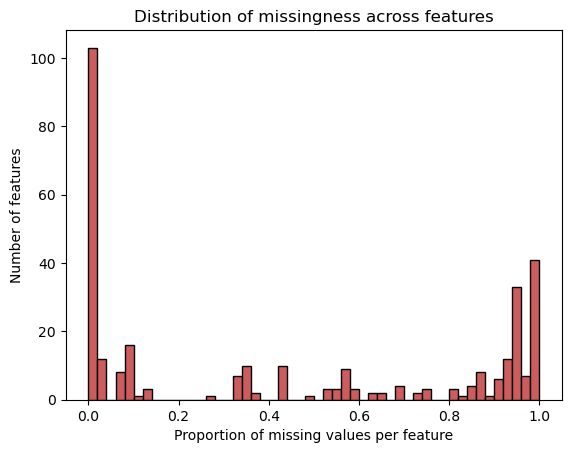


Missingness categories:
  0%–5%: 115 features
  5%–20%: 28 features
  20%–50%: 31 features
  50%–100%: 147 features


In [10]:
perc_missing = de.analyze_missingness(x_train)

- 0-20% : Impute directly
- 20-50% : Keep if they look predictive and impute
- '>50%' : Should likely drop them

### y_train balance
First observation : y_train highly imbalanced

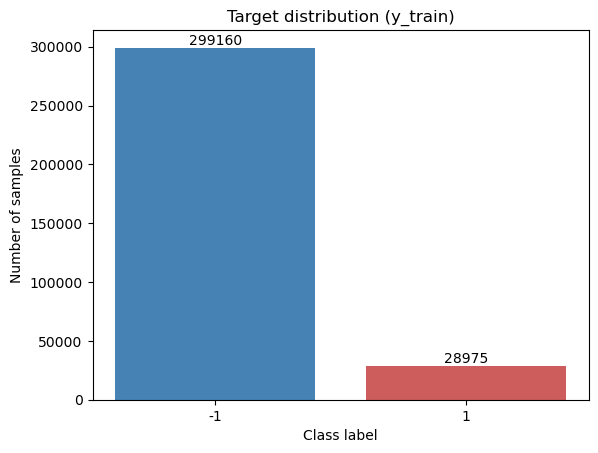

In [11]:
de.plot_target_distribution(y_train)

Important to use other metrics during evaluation (e.g. F1-score). Preprocessing : duplication or deletion to achieve balanced y_train.

### Constant and near-constant features

In [ ]:
const_feats = de.find_constant_features(x_train)
print("Constant features:", const_feats)
print("Number of constant features:", len(const_feats))

Constant features: [9, 11, 12, 18, 19, 22]
Number of constant features: 6


In [ ]:
near_const_feats = de.find_near_constant_features(x_train)
print("Near-constant features:", near_const_feats)
print("Number of near-constant features:", len(near_const_feats))


Near-constant features: [280, 281]
Number of near-constant features: 2


Constant features can be dropped immediately during preprocessing. Near constant no, be careful.

In [ ]:
de.analyze_near_constant_features(x_train, y_train, near_const_feats)


Feature 280 (unique=2, most frequent=99.98%)
  value 0.0: count=70, positives=9 (12.86%)
  value 1.0: count=328065, positives=28966 (8.83%)

Feature 281 (unique=2, most frequent=99.99%)
  value 0.0: count=39, positives=3 (7.69%)
  value 1.0: count=328096, positives=28972 (8.83%)


We see that the most frequent is > 99.5%. More than likely that its not going to be useful to the model as it's clearly not correlated to the target. Can be dropped.

### Feature scales and distributions

Global min across features: 0.00
Global max across features: 2015023235.00
Median std across features: 1.37
Features with std < 1e-6: 6
Features with std > 1e3: 10


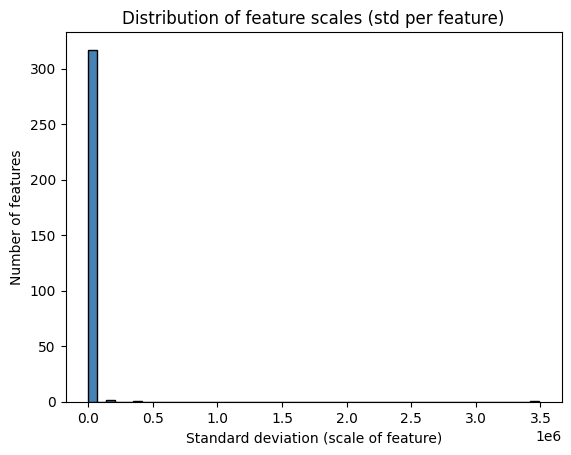

Features with std < 1e-6: [ 9 11 12 18 19 22]
Features with std > 1e3: [  2   7   8  62  63 101 105 219 226 264]


In [ ]:
mins, maxs, stds = de.feature_scale_summary(x_train)
de.plot_feature_stds(stds)
small, large = de.extreme_scale_features(stds)
print("Features with std < 1e-6:", small)
print("Features with std > 1e3:", large)



Distribution of feature scales : Shows that most features share a similar scale which is good.

Features with std < 1e-6: [ 9 11 12 18 19 22] == Constant features identified earlier. Will be dropped.

--> Analyze features with very large std


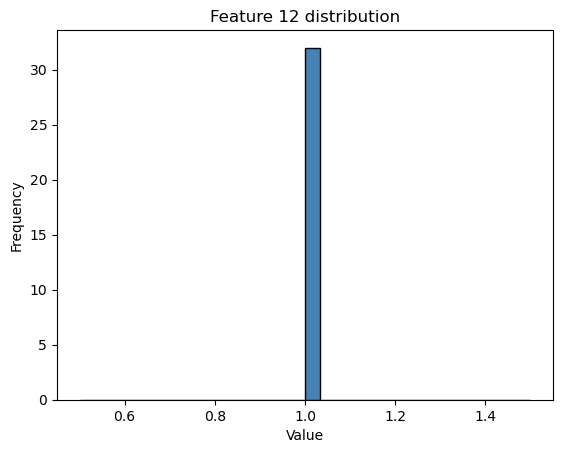

In [47]:
"""
de.plot_feature_distribution(x_train, 2)
de.plot_feature_distribution(x_train, 219)
de.plot_feature_distribution(x_train, 62)
de.plot_feature_distribution(x_train, 63)
de.plot_feature_distribution(x_train, 101)
de.plot_feature_distribution(x_train, 105)
de.plot_feature_distribution(x_train, 264)
"""
de.plot_feature_distribution(x_train, 12)
### Analysis
# Features do not seem to be continuous. Could be IDs or code-like features. Need encoding as categorical.

In [ ]:
de.plot_feature_distribution(x_train, 7)
de.plot_feature_distribution(x_train, 8)
de.plot_feature_distribution(x_train, 226)
### Analysis
# Feature 7 and 8 seem to be the same feature.
# All look like power law distribution. Try log-transforming them.

### Feature types

- Detect categorical vs continuous vs binary :
    - Continuous: many distinct numeric values, e.g. height, BMI.
    - Categorical: few distinct values, e.g. blood type, region.
    - Binary: two distinct values, e.g. gender (0/1), yes/no responses.

- Plot frequency bar charts for categorical features.

In [176]:
importlib.reload(de)  


categorical, continuous, binary, ignored = de.detect_feature_types_refined(x_train_nosurveycode)
print("Categorical features (example):", categorical[:20])
print("Continuous features (example):", continuous[:20])
print("Binary/Pseudo-binary features (example):", binary[:20])
print("Ignored features (example):", ignored[:20])

print(f"Total categorical: {len(categorical)}, continuous: {len(continuous)}, binary: {len(binary)}, ignored: {len(ignored)}")



#categorical, continuous = de.detect_feature_types(x_train_nosurveycode)
#print("Categorical features (example):", categorical[:20])
#print("Continuous features (example):", continuous[:20])
#print(f"Total categorical: {len(categorical)}, continuous: {len(continuous)}")




Categorical features (example): [4, 6, 7, 10, 21, 24, 25, 26, 31, 33, 46, 48, 49, 70, 71, 72, 75, 79, 81, 88]
Continuous features (example): [0, 1, 2, 22, 32, 35, 36, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63]
Binary/Pseudo-binary features (example): [3, 5, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 27, 29, 30, 34, 37]
Ignored features (example): [28, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112, 113, 114, 118, 119, 120, 121, 122]
Total categorical: 66, continuous: 74, binary: 88, ignored: 66


In [14]:
suspect_features = de.detect_date_or_id_features(x_train[:, continuous])
removed_from_continuous = []


for idx in suspect_features:
    if idx in continuous:
        removed_from_continuous.append(idx)
        continuous.remove(idx)

print("Removed suspect date/ID-like features:", suspect_features)
print("Number:", len(removed_from_continuous))
print("len of continuous:", len(continuous))

Removed suspect date/ID-like features: [1, 3, 4, 5, 6, 15, 34, 35, 36, 43, 48, 49, 66, 83, 84, 86, 87, 88, 89, 90, 91]
Number: 10
len of continuous: 82


In [15]:
feature_names = np.genfromtxt("dataset/x_test.csv", delimiter=",", dtype=str, max_rows=1)

for j in removed_from_continuous:
    col = x_train[:, j]
    name = feature_names[j+1] if j < len(feature_names) else f"Feature_{j+1}"
    print(f"{name} (index {j}): mean={np.mean(col)}, min={np.nanmin(col)}, max={np.nanmax(col)}, unique={len(np.unique(col[~np.isnan(col)]))}")

    

IDAY (index 4): mean=14.496234781416186, min=1.0, max=31.0, unique=31
NUMADULT (index 15): mean=nan, min=1.0, max=20.0, unique=16
DIABAGE2 (index 49): mean=nan, min=1.0, max=99.0, unique=98
FVBEANS (index 83): mean=nan, min=101.0, max=999.0, unique=108
FVGREEN (index 84): mean=nan, min=101.0, max=999.0, unique=115
VEGETAB1 (index 86): mean=nan, min=101.0, max=999.0, unique=133
EXRACT11 (index 88): mean=nan, min=1.0, max=99.0, unique=77
EXEROFT1 (index 89): mean=nan, min=101.0, max=999.0, unique=115
EXERHMM1 (index 90): mean=nan, min=1.0, max=999.0, unique=194
EXRACT21 (index 91): mean=nan, min=1.0, max=99.0, unique=78


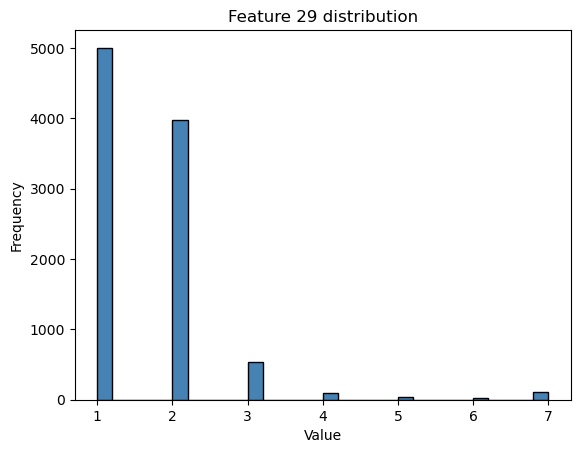

Unique values (without NaN): [1. 2. 3. 4. 5. 6. 7.]
Counts: [5004 3978  533   97   32   27  113]
NaN count: 318351
NaN ratio: 0.9702
Min: 1.0
Max: 7.0
Mean (ignoring NaN): 1.641455437448896


In [173]:
f = 28  # index of the feature you want to inspect

de.plot_feature_distribution(x_train_nosurveycode, f+1)
col = x_train_nosurveycode[:, f]


# 1️⃣ Compte des valeurs uniques (hors NaN)
unique_vals, counts = np.unique(col[~np.isnan(col)], return_counts=True)
print("Unique values (without NaN):", unique_vals)
print("Counts:", counts)

# 2️⃣ Nombre et proportion de NaN
n_nan = np.isnan(col).sum()
print("NaN count:", n_nan)
print(f"NaN ratio: {n_nan / len(col):.4f}")

# 3️⃣ Statistiques simples
print("Min:", np.nanmin(col))
print("Max:", np.nanmax(col))
print("Mean (ignoring NaN):", np.nanmean(col))

In [ ]:
print(feature_names)


Indices trouvés : [12, 35, 36, 38, 40, 158]


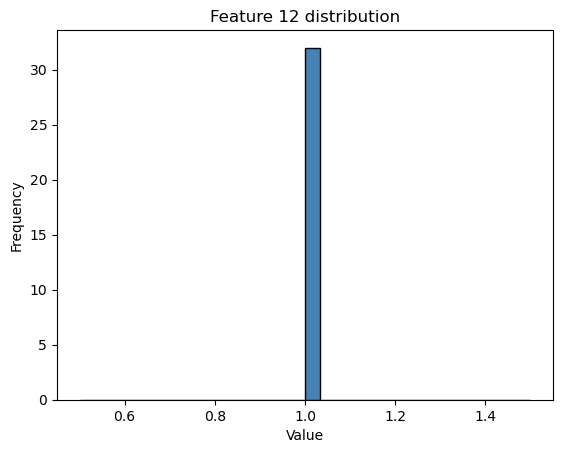

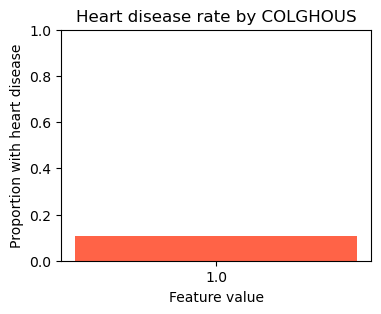

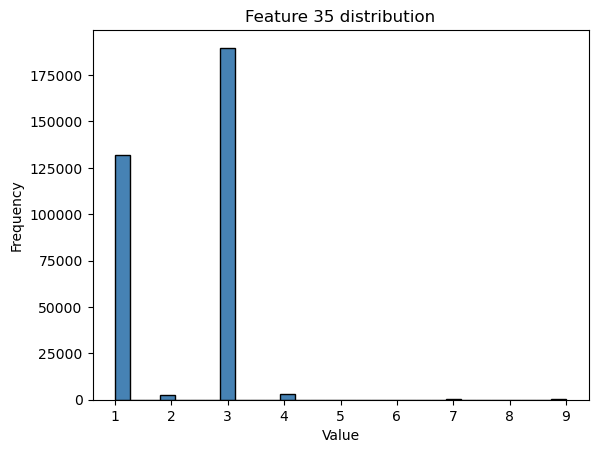

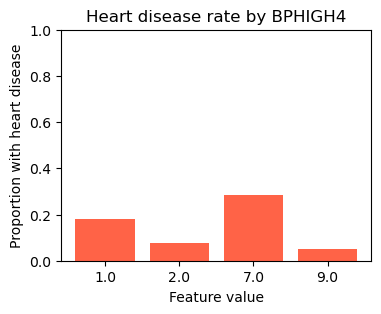

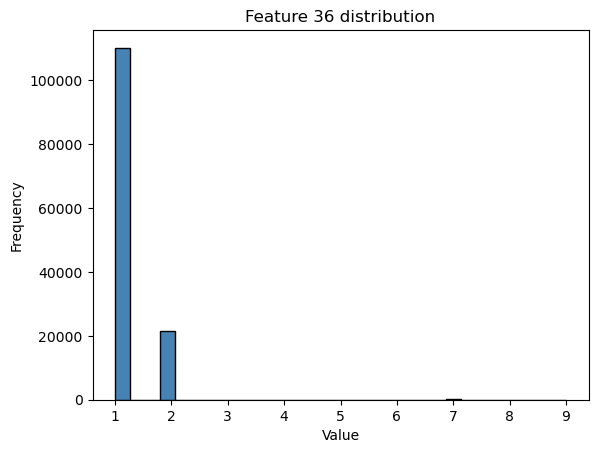

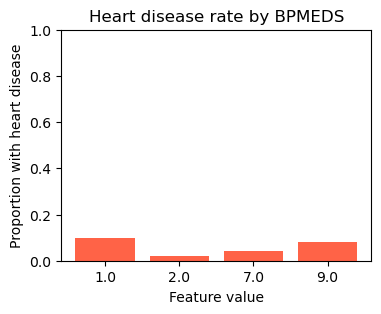

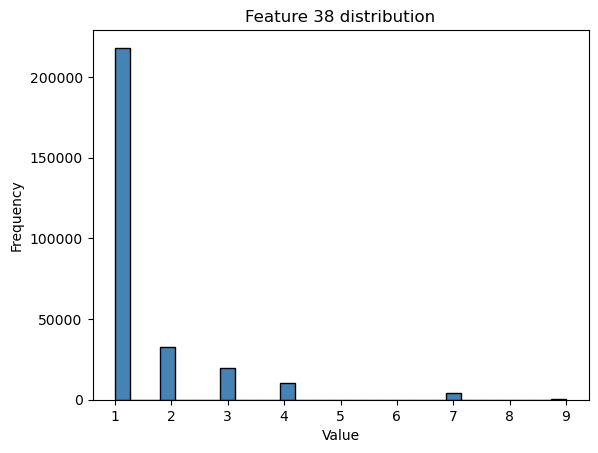

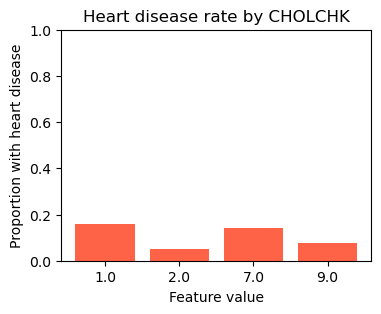

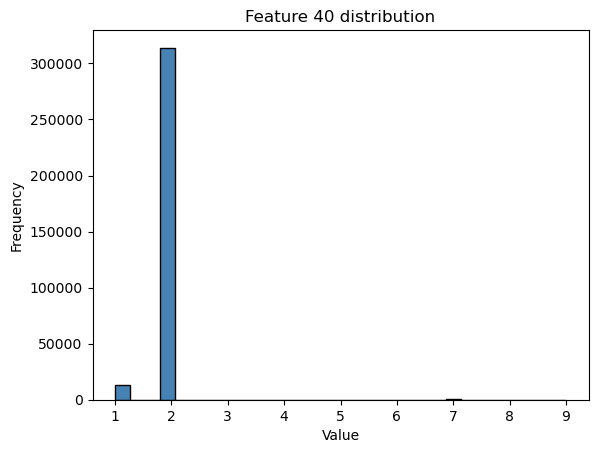

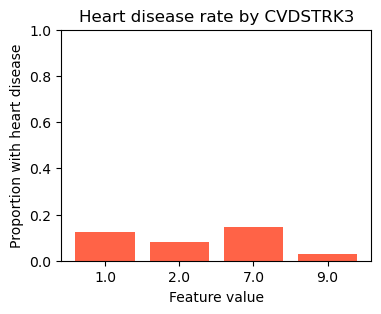

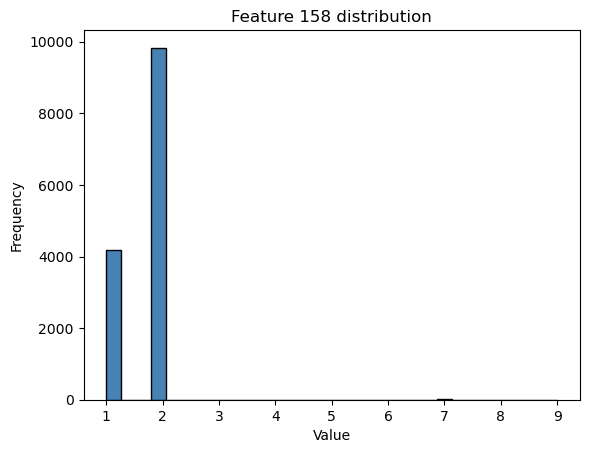

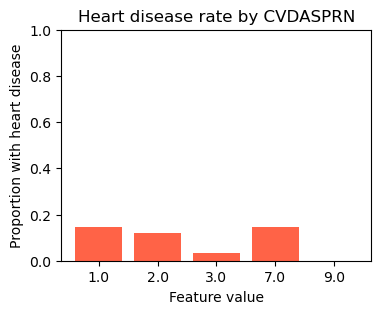

In [49]:
# Exemple : ton array x_train et la liste de noms de colonnes
# Si tu as un DataFrame, adapte avec pandas (plus bas)
features_to_plot = ["_MICHD", "BPHIGH4", "BPMEDS", "CVDSTRK3", "CVDASPRN", "CHOLCHK"]


y_bin = (y_train == 1).astype(int)


# indices correspondants à ces noms
indices = [i for i, name in enumerate(feature_names) if name in features_to_plot]
print("Indices trouvés :", indices)



for idx in indices:
    
    de.plot_feature_distribution(x_train, idx)

    col = x_train[:, idx]
    col_nonan = col[~np.isnan(col)]
    y_sub = y_bin[~np.isnan(col)]
    unique_vals = np.unique(col_nonan)
    
    proportions = []
    for val in unique_vals:
        mask = col_nonan == val
        prop = y_sub[mask].mean()  # proportion de malades pour cette valeur
        proportions.append(prop)
    
    plt.figure(figsize=(4, 3))
    plt.bar(unique_vals.astype(str), proportions, color='tomato')
    plt.title(f"Heart disease rate by {feature_names[idx]}")
    plt.xlabel("Feature value")
    plt.ylabel("Proportion with heart disease")
    plt.ylim(0, 1)
    plt.show()

### Correlation analysis

- Compute correlation (Pearson for continuous).

- Visualize with a heatmap to spot redundant features.

In [129]:
#Compute correlation matrix for continuous features
features_to_check = [7, 8, 222, 226, 229, 253]
corr_matrix = de.compute_feature_correlation(x_train, features_to_check)
print(corr_matrix)

[[ 1.          1.          0.0903047  -0.03695394  0.05003009  0.057021  ]
 [ 1.          1.          0.0903047  -0.03695394  0.05003009  0.057021  ]
 [ 0.0903047   0.0903047   1.          0.29837661  0.72572913 -0.01402237]
 [-0.03695394 -0.03695394  0.29837661  1.          0.3049719  -0.00446365]
 [ 0.05003009  0.05003009  0.72572913  0.3049719   1.         -0.01588941]
 [ 0.057021    0.057021   -0.01402237 -0.00446365 -0.01588941  1.        ]]


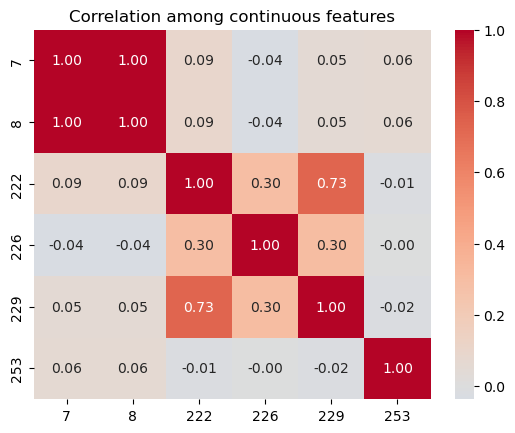

In [130]:
#Visualize the correlation matrix with heatmap
sns.heatmap(corr_matrix, xticklabels=features_to_check, yticklabels=features_to_check,
            cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation among continuous features")
plt.show()


### #TODO Dependencies analysis

- Identify dependancies between features

In [160]:
importlib.reload(de)  

# 1. Limit to discrete features
mask_disc = np.array([
    len(np.unique(x_train_nosurveycode[:, i][~np.isnan(x_train_nosurveycode[:, i])])) < 10
    for i in range(x_train_nosurveycode.shape[1])
])
x_disc = x_train_nosurveycode[:, mask_disc]
names_disc = [f for f, m in zip(feature_names_without_meta, mask_disc) if m]

# 2. 50k lines
idx = np.random.choice(x_disc.shape[0], 50000, replace=False)
x_sample = x_disc[idx]

groups, deps = de.detect_hierarchical_dependencies(x_sample, names_disc)

#for a, val, b, p1, p0 in deps:
#    print(f"{b} depends on {a}={val}: P(B|A={val})={p1}, P(B|A≠{val})={p0}")

Detected 170 dependencies.
BPHIGH4 depends on CHECKUP1==1.0 (value-based, ratio=0.999)
_HCVU651 depends on CHECKUP1 (presence-based, ratio=1.0)
_CHOLCHK depends on CHOLCHK (presence-based, ratio=1.0)
_RFCHOL depends on CVDSTRK3 (presence-based, ratio=1.0)
_LTASTH1 depends on CVDSTRK3 (presence-based, ratio=0.996)
_CASTHM1 depends on CVDSTRK3 (presence-based, ratio=0.996)
_ASTHMS1 depends on CHCCOPD1 (presence-based, ratio=1.0)
MARITAL depends on DIABAGE2 (presence-based, ratio=0.996)
CPDEMO1 depends on DIABAGE2 (presence-based, ratio=0.998)
VETERAN3 depends on DIABAGE2 (presence-based, ratio=1.0)
ADANXEV depends on DIABAGE2 (presence-based, ratio=1.0)
QSTVER depends on DIABAGE2 (presence-based, ratio=1.0)
_LLCPWT depends on DIABAGE2 (presence-based, ratio=0.997)
_HCVU651 depends on DIABAGE2 (presence-based, ratio=0.997)
_RFCHOL depends on DIABAGE2 (presence-based, ratio=0.997)
_HISPANC depends on DIABAGE2 (presence-based, ratio=1.0)
_AGEG5YR depends on DIABAGE2 (presence-based, ratio=1

- Features 7 and 8 are the same feature as suspected before. Need to drop one.
- Features 222 and 229 are highly correlated but not enough to drop one for now. Could try to explore interaction?

In [161]:
importlib.reload(de)  

cleaned_groups, to_remove, encoding_plan = de.process_dependency_groups(
    x_train_nosurveycode,     # complete dataset (cleaned NaN)
    feature_names_without_meta,
    groups,                   
    verbose=True              # pour avoir un résumé à l’écran
)



=== Dependency Group Processing Summary ===
Removed 0 constant features:

Optimized to 29 dependency groups:
  BPHIGH4 → CHECKUP1 → _HCVU651
  CHOLCHK → _CHOLCHK
  CVDSTRK3 → _CASTHM1 → _LTASTH1 → _RFCHOL
  CHCCOPD1 → _ASTHMS1
  ADANXEV → CPDEMO1 → DIABAGE2 → MARITAL → QSTVER → VEGEDA1_ → VETERAN3 → _AGE80 → _AGEG5YR → _CHLDCNT → _FRT16 → _FRTLT1 → _FRTRESP → _FRUITEX → _HISPANC → _LLCPWT → _MISFRTN → _MISVEGN → _VEG23 → _VEGESUM → _VEGLT1
  NUMPHON2 → RENTHOM1 → _CLLCPWT
  CHILDREN → _EDUCAG
  DIFFALON → SMOKE100 → _INCOMG → _SMOKER3
  STRFREQ_ → VEGETAB1 → _VEGETEX
  PNEUVAC3 → _PNEUMO2
  DIABEYE → PREDIAB1
  CRGVLNG1 → CRGVPERS → CRGVPRB1
  CRGVEXPT → VIDFCLT2
  VIINSUR2 → VIPRFVS2
  ASATTACK → ASTHMAGE → ASTHMED3
  ASPUNSAF → STREHAB1
  ARTHEXER → ARTTODAY
  HOWLONG → SHINGLE2
  HADSGCO1 → LSTBLDS3
  PCPSADE1 → PCPSARS1
  RCSGENDR → TRNSGNDR
  _CHISPNC → _CRACE1
  _DRDXAR1 → _PRACE1
  _RACE → _RACEG21 → _RACEGR3
  _BMI5 → _BMI5CAT
  PA1VIGM_ → _PA150R2 → _PA300R2
  _PACAT1 → _PAIN

# Data Cleaning & Feature Processing Pipeline

### Handle missing values

- If missing values exist:
    - For continuous: replace with mean/median.
    - For categorical: replace with mode or add “unknown” category.
    
- Document how many replacements you did.

### Remove or combine useless features

- Drop irrelevant features (id, date,...) (introducing irrelevant noise + data leakage)

- Drop constant columns (variance = 0).

- Merge highly correlated/redundant features if appropriate.

In [96]:
# Detect constant features
const_feats = de.find_constant_features(x_train)
print("Constant features detected:", const_feats)
print("Number of constant features:", len(const_feats))

# Detect near-constant features
near_const_feats = de.find_near_constant_features(x_train, threshold=0.95)
print("Near-constant features detected:", near_const_feats)
print("Number of near-constant features:", len(near_const_feats))

# Combine both sets
to_remove = list(set(const_feats) | set(near_const_feats))
print("Total features to remove (constant + near-constant):", len(to_remove))

Constant features detected: [9, 11, 12, 18, 19, 22]
Number of constant features: 6
Near-constant features detected: [5, 39, 47, 217, 280, 281]
Number of near-constant features: 6
Total features to remove (constant + near-constant): 12


In [97]:
# Drop them from training and test sets
x_train_remove = np.delete(x_train, to_remove, axis=1)
x_test_remove = np.delete(x_test, to_remove, axis=1)

print("Original number of features:", x_train.shape[1])
print("New number of features after removal:", x_train_remove.shape[1])

Original number of features: 321
New number of features after removal: 309


In [102]:
suspect_feats = de.find_suspicious_features(x_train, y_train, corr_threshold=0.2)

print("Suspicious features detected:")
for f, reason, score in suspect_feats:
    print(f"Feature {f}: {reason}, score={score}")

Suspicious features detected:
Feature 2: Large range (maybe date/ID), score=11299999.0
Feature 58: High correlation, score=0.20718614349707698
Feature 246: High correlation, score=0.21900688187283118
Feature 248: High correlation, score=0.22454741432663888
Feature 249: High correlation, score=0.20687285866885363


### Standardize/normalize features

- Continuous features: subtract mean and divide by std ((x - mean)/std).

- This is crucial for gradient-based methods.

In [216]:
"""x_train_norm, x_test_norm = de.standardize(x_train, x_test)

print("Original mean (feature 0):", np.mean(x_train[:,0]))
print("Normalized mean (feature 0):", np.mean(x_train_norm[:,0]))

print("Original std (feature 0):", np.std(x_train[:,0]))
print("Normalized std (feature 0):", np.std(x_train_norm[:,0]))"""


x_train_cont_std, x_test_cont_std = de.standardize(x_train_2[:, continuous_train], x_test_2[:, continuous_train])

print("Original mean (feature 0):", np.mean(x_train_2[:,0]))
print("Normalized mean (feature 0):", np.mean(x_train_cont_std[:,0]))

print("Original std (feature 0):", np.std(x_train_2[:,0]))
print("Normalized std (feature 0):", np.std(x_train_cont_std[:,0]))

Original mean (feature 0): 29.973651088728726
Normalized mean (feature 0): -9.843897410411615e-17
Original std (feature 0): 16.031752874847626
Normalized std (feature 0): 1.0


### Encode categorical features

- Binary encoding: already 0/1 (keep as is).
- Multi-category: one-hot encoding using NumPy.

Careful not to create too many features.

In [218]:
x = np.array([
    [1, 2, np.nan],
    [2, 2, 1],
    [1, 1, 2],
    [3, 2, 1]
], dtype=float)

names = ["Q1", "Q2", "Q3"]

x_encoded, new_names, skipped = de.one_hot_encode_numpy(x, feature_names=names, max_categories=5)

print("Encoded shape:", x_encoded.shape)
print("Encoded columns:", new_names)
print("Skipped features:", skipped)

Encoded shape: (4, 7)
Encoded columns: ['Q1=1', 'Q1=2', 'Q1=3', 'Q2=1', 'Q2=2', 'Q3=1', 'Q3=2']
Skipped features: []


### Outlier handling (optional)
- Winsorization (clip extreme values).

Only if distributions show extreme anomalies.

In [99]:
feature_types = de.detect_feature_types(x_train)
numeric_features_idx = feature_types[0]
continuous_features_idx = feature_types[1]

In [36]:
print("Number of numeric features detected", len(numeric_features_idx))
print("Number of continuous features detected", len(continuous_features_idx))

Number of numeric features detected 315
Number of continuous features detected 6


In [48]:
numeric_outlier_report = []
for f in numeric_features_idx:
    values = x_train[:, f]
    #METAPARAMETER
    q01, q99 = np.percentile(values, [1, 99])
    min_val, max_val = values.min(), values.max()
    if min_val < q01 or max_val > q99:
        numeric_outlier_report.append((f, min_val, max_val, q01, q99))

In [49]:
print("Features with potentials outliers :")
for f, min_val, max_val, q01, q99 in numeric_outlier_report:
    print(f"Feature {f}: min={min_val}, max={max_val}, "
          f"1%={q01:.2f}, 99%={q99:.2f}")

Features with potentials outliers :
Feature 2: min=1012016.0, max=12312015.0, 1%=1072016.00, 99%=12232015.00
Feature 28: min=1.0, max=99.0, 1%=1.00, 99%=88.00
Feature 30: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 31: min=1.0, max=9.0, 1%=1.00, 99%=3.00
Feature 36: min=1.0, max=9.0, 1%=1.00, 99%=7.00
Feature 39: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 40: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 43: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 44: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 46: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 47: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 51: min=1.0, max=9.0, 1%=1.00, 99%=6.00
Feature 52: min=1.0, max=9.0, 1%=2.00, 99%=6.00
Feature 53: min=1.0, max=9.0, 1%=1.00, 99%=3.00
Feature 58: min=1.0, max=9.0, 1%=1.00, 99%=8.00
Feature 219: min=11011.0, max=722019.0, 1%=12039.00, 99%=721041.00
Feature 221: min=0.3333333333333333, max=5.0, 1%=1.00, 99%=4.00
Feature 230: min=1.0, max=9.0, 1%=1.00, 99%=2.00
Feature 232: min=1.0, max=9.0, 1%=1.0


Visualisation of feature 28


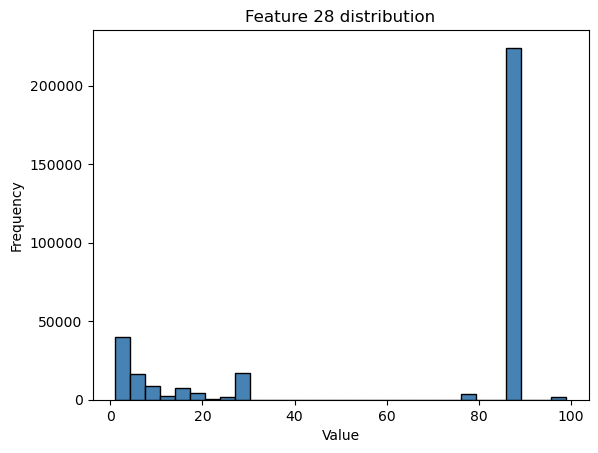

In [68]:
if numeric_outlier_report:
    feature_id = numeric_outlier_report[1][0]
    print(f"\nVisualisation of feature {feature_id}")
    de.plot_feature_distribution(x_train, feature_id)

In [52]:
continuous_outlier_report = []
for f in continuous_features:
    values = x_train[:, f]
    q01, q99 = np.percentile(values, [1, 99])
    min_val, max_val = values.min(), values.max()
    if min_val < q01 or max_val > q99:
        continuous_outlier_report.append((f, min_val, max_val, q01, q99))

In [53]:
print("Continuous features with potential outliers :")
for f, min_val, max_val, q01, q99 in continuous_outlier_report:
    print(f"Feature {f}: min={min_val}, max={max_val}, "
          f"1%={q01:.2f}, 99%={q99:.2f}")

Continuous features with potential outliers :
Feature 7: min=2015000001.0, max=2015023235.0, 1%=2015000082.00, 99%=2015018905.32
Feature 8: min=2015000001.0, max=2015023235.0, 1%=2015000082.00, 99%=2015018905.32
Feature 222: min=0.3627727202146234, max=3191.946865431815, 1%=2.90, 99%=753.16
Feature 229: min=1.4335054328182186, max=33134.939618228345, 1%=10.24, 99%=4707.03



Visualisation of feature 222


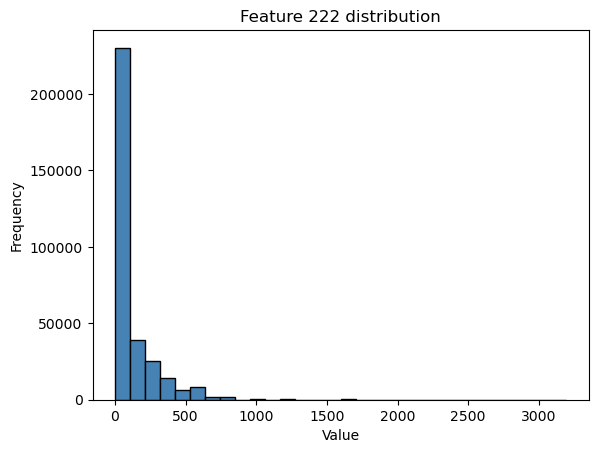

In [65]:
if continuous_outlier_report:
    feature_id = continuous_outlier_report[2][0]
    print(f"\nVisualisation of feature {feature_id}")
    de.plot_feature_distribution(x_train, feature_id)

In [ ]:
#Observation : features 7 et 8 semblent etre des id aussi


[numeric] Individuals without outlier: 286945, with outlier: 41190


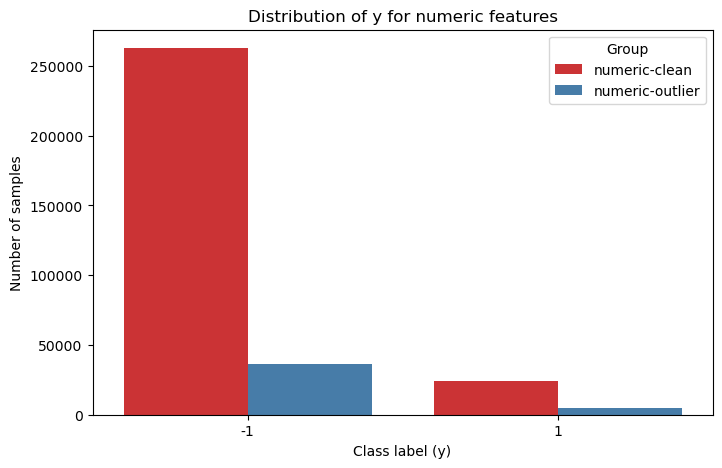


[continuous] Individuals without outlier: 312217, with outlier: 15918


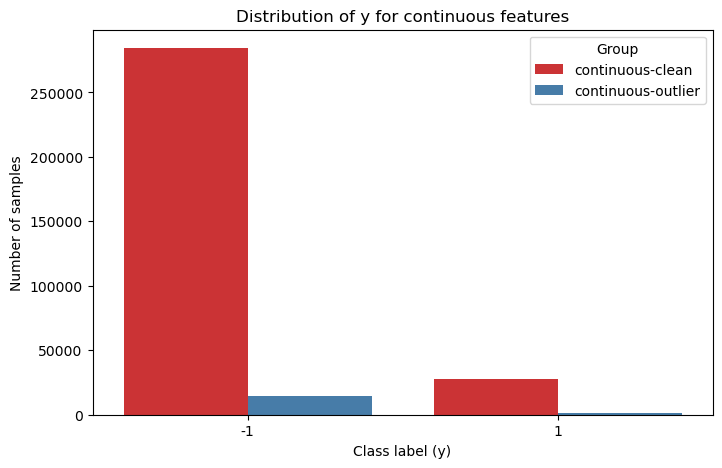

In [82]:
# Comparison for numeric features
de.compare_y_distribution_from_report(x_train, y_train, numeric_outlier_report, numeric_features_idx, "numeric")

# Comparison for continuous features
de.compare_y_distribution_from_report(x_train, y_train, continuous_outlier_report, continuous_features, "continuous")


In [46]:
#Observation : outliers do not seem to matter in predicting y

### Survey code Outliers handling

In [ ]:
importlib.reload(de)  

x = np.array([
    [1], [2], [3], [4], [5], [7], [9]
], dtype=float)

names = ["smoke"]

x_clean = de.clean_survey_codes(x)
print(x_clean)


x_train_nosurveycode = de.clean_survey_codes(x_train[:, 27:]  , feature_names=feature_names_without_meta)
#x_test_1 = de.replace_survey_codes_by_pattern(x_test, feature_names=feature_names)


In [135]:
x_train_nosurveycode.shape

(328135, 311)

### Feature engineering (optional for bonus)

- Combine existing features (e.g., BMI categories, interaction terms).

- Apply transformations (log for skewed distributions).

In [ ]:
for i, name in enumerate(feature_names):
    print(i, name)